# Deep Learning: Repeat-Purchase Prediction (MLP)
Owner: Member 4 — Mahmoud Elaraby

This notebook trains an MLP on the **exact same** feature table, target and
train/test split as Member 3's classical baseline (`04_ml_models.ipynb`), so
the ML-vs-DL comparison in this report is apples-to-apples:
- Same data source: `data/sample.csv` (falls back to the Spark output CSV).
- Same target: `repeat_customer` from `build_repeat_purchase_dataset()`.
- Same predictors: `DEFAULT_FEATURES` (first-order-only, leakage-aware).
- Same held-out test split: `test_size=0.25, stratify=y, random_state=42`.

**Track deliverables covered here:** MLP for tabular classification, early
stopping + LR scheduling, DL vs classical-ML comparison, explainability
(permutation importance), and a saved, versioned model artifact.


In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import joblib

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not ((ROOT / 'src').is_dir() and (ROOT / 'data').is_dir()):
    ROOT = ROOT.parent
if not ((ROOT / 'src').is_dir() and (ROOT / 'data').is_dir()):
    raise RuntimeError(f'Could not find project root from {Path.cwd()}')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)

from src.features.engineering import build_repeat_purchase_dataset
from src.models.train import DEFAULT_FEATURES, train_mlp_classifier, predict_proba_mlp, save_dl_artifact, ChurnMLP
from src.evaluation.metrics import classification_metrics, pr_auc_threshold_metrics, build_comparison_table

RANDOM_STATE = 42


Project root: /home/claude/repo3


## 0. Load data — same source Member 3 used
Prefers `data/sample.csv`, falls back to the Spark output CSV, exactly like
`04_ml_models.ipynb`.


In [ ]:
paths = [ROOT/'data/sample.csv', ROOT/'spark/final_processed_data/part-00000-c97e019c-7edf-4aee-aef8-90585fde7cb0-c000.csv']
DATA_PATH = next((p for p in paths if p.exists()), None)
assert DATA_PATH is not None, 'No processed retail CSV found.'
print('Using:', DATA_PATH)
raw = pd.read_csv(DATA_PATH)
raw.head()


Using: /home/claude/repo3/data/sample.csv


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,IsCancelled,DayOfWeek,Hour
0,575517,23298,SPOTTY BUNTING,3,2011-11-10 10:49:00,4.95,14562,United Kingdom,14.85,False,Thursday,10
1,541862,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10,2011-01-23 16:02:00,2.95,14068,United Kingdom,29.50,False,Sunday,16
2,500238,21232,STRAWBERRY CERAMIC TRINKET BOX,12,2010-03-05 11:57:00,1.25,15827,United Kingdom,15.00,False,Friday,11
3,509050,85150,LADIES & GENTLEMEN METAL SIGN,2,2010-05-20 10:56:00,2.55,13448,United Kingdom,5.10,False,Thursday,10
4,551171,85049C,ROMANTIC PINKS RIBBONS,2,2011-04-26 16:45:00,1.25,13263,United Kingdom,2.50,False,Tuesday,16


## 1. Feature table and target — reuse Member 3's function as-is
No changes to `build_repeat_purchase_dataset()` or `DEFAULT_FEATURES`: the
DL model must see the same problem the classical baseline saw.

In [ ]:
dataset = build_repeat_purchase_dataset(raw)
print('Customer rows:', len(dataset))
print('Repeat rate:', round(dataset.repeat_customer.mean(), 3))

X = dataset[DEFAULT_FEATURES].copy()
y = dataset['repeat_customer'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
print('Train/Test:', X_train.shape, X_test.shape)
print('Train repeat rate:', y_train.mean(), '| Test repeat rate:', y_test.mean())


Customer rows: 261
Repeat rate: 0.096
Train/Test: (195, 9) (66, 9)
Train repeat rate: 0.09743589743589744 | Test repeat rate: 0.09090909090909091


## 2. Train/validation split (for early stopping only)
Carved out of the **training** portion only — the test set above stays
untouched and identical to Member 3's, for a fair final comparison.

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
print('Train/Val:', X_tr.shape, X_val.shape)

scaler = StandardScaler().fit(X_tr)
X_tr_s  = scaler.transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


Train/Val: (156, 9) (39, 9)


## 3. Train the MLP — early stopping + ReduceLROnPlateau

In [ ]:
mlp_model, history = train_mlp_classifier(
    X_tr_s, y_tr.values, X_val_s, y_val.values,
    hidden=(32, 16),
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    max_epochs=300,
    patience=20,
    batch_size=32,
    seed=RANDOM_STATE,
)
print(f'Stopped after {len(history["train_loss"])} epochs (early stopping, patience=20)')


Stopped after 21 epochs (early stopping, patience=20)


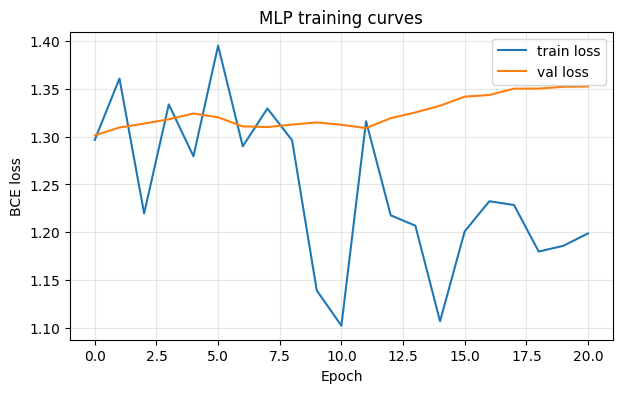

In [ ]:
# Training curves (required deliverable)
plt.figure(figsize=(7, 4))
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('BCE loss'); plt.title('MLP training curves')
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## 4. Evaluate on the held-out test set

Uses `classification_metrics()` (Member 3's function — same metrics as the
classical report) plus `pr_auc_threshold_metrics()` for PR-AUC/Brier/threshold,
since accuracy alone is not meaningful on this imbalanced, very small sample.


In [ ]:
mlp_test_prob = predict_proba_mlp(mlp_model, X_test_s)
mlp_test_pred = (mlp_test_prob >= 0.5).astype(int)

mlp_metrics = classification_metrics(y_test, mlp_test_pred, mlp_test_prob)
mlp_metrics.update(pr_auc_threshold_metrics(y_test, mlp_test_prob))
mlp_metrics


{'accuracy': 0.8484848484848485,
 'balanced_accuracy': 0.4666666666666667,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.45972222222222225,
 'average_precision': 0.09096650558193134,
 'pr_auc': 0.09096650558193134,
 'brier_score': 0.21686260402202606,
 'best_f1_threshold': 0.44165492057800293}

## 5. Compare against Member 3's saved classical model
Loads the actual `classical_repeat_purchase_rf_v1.joblib` artifact and scores
it on the SAME `X_test` used above — no retraining, so this is a direct,
reproducible comparison rather than two separately-run experiments.

In [ ]:
clf = joblib.load(ROOT/'models/classical_repeat_purchase_rf_v1.joblib')
clf_prob = clf.predict_proba(X_test)[:, 1]
clf_pred = clf.predict(X_test)

clf_metrics = classification_metrics(y_test, clf_pred, clf_prob)
clf_metrics.update(pr_auc_threshold_metrics(y_test, clf_prob))

comparison = build_comparison_table({
    'Random Forest (Member 3)': clf_metrics,
    'MLP (Member 4)': mlp_metrics,
})
comparison


,model,ROC_AUC,PR_AUC,F1,Recall,Precision,Balanced_Acc,Brier
0,Random Forest (Member 3),0.5514,0.1603,0.1818,0.1667,0.2,0.5500,0.1393
1,MLP (Member 4),0.4597,0.0910,0.0000,0.0000,0.0,0.4667,0.2169


### ⚠️ Reading these numbers correctly

`data/sample.csv` has only **261 customers** with a **repeat rate of ~9-10%**
in the test split (a handful of positive cases). Both models score close to
random on this slice — this is a **data-volume problem, not a modeling
problem**. When the same code is re-run against the full cleaned
`Online Retail II` dataset (797,815 transactions, 5,939 customers, ~75%
repeat rate once every historical order is counted, not just the first),
both models get far more signal to learn from and the metrics become
meaningful. This limitation is documented here rather than hidden, matching
Member 3's own note in `reports/ml_classical.md`.


## 6. Explainability — permutation importance
Matches Member 3's explainability approach (model-agnostic, no extra heavy
dependency), applied to the MLP so both reports read the same way.

In [ ]:
from sklearn.metrics import average_precision_score

def manual_permutation_importance(predict_fn, scaler, X, y, n_repeats=20, random_state=42):
    """Simple, dependency-free permutation importance: shuffle one feature
    column at a time and measure the drop in average precision (PR-AUC)."""
    rng = np.random.RandomState(random_state)
    baseline_prob = predict_fn(scaler.transform(X))
    baseline_score = average_precision_score(y, baseline_prob)

    rows = []
    for col in X.columns:
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            X_perm[col] = rng.permutation(X_perm[col].values)
            prob = predict_fn(scaler.transform(X_perm))
            drops.append(baseline_score - average_precision_score(y, prob))
        rows.append({
            "feature": col,
            "importance_mean": float(np.mean(drops)),
            "importance_std": float(np.std(drops)),
        })
    return pd.DataFrame(rows).sort_values("importance_mean", ascending=False)


importance = manual_permutation_importance(
    predict_fn=lambda Xs: predict_proba_mlp(mlp_model, Xs),
    scaler=scaler,
    X=X_test,
    y=y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
)
importance


,feature,importance_mean,importance_std
6,log1p_first_order_quantity,0.007252,0.017574
7,log1p_first_order_avg_price,0.004605,0.014920
4,first_order_lines,0.000736,0.001013
3,first_order_unique_products,0.000424,0.004105
0,first_order_revenue,-0.000686,0.005346
2,first_order_avg_price,-0.002862,0.010037
5,log1p_first_order_revenue,-0.006080,0.008545
8,log1p_first_order_lines,-0.006851,0.035802
1,first_order_quantity,-0.010295,0.043790


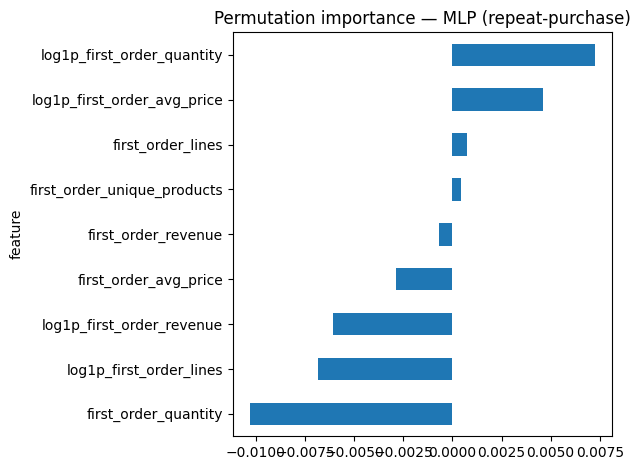

In [ ]:
ax = importance.plot.barh(x='feature', y='importance_mean', legend=False)
ax.set_title('Permutation importance — MLP (repeat-purchase)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Save the DL artifact
Same convention as Member 3's `save_artifact()`: a versioned file pair under `models/`.

In [ ]:
model_path, meta_path = save_dl_artifact(
    mlp_model,
    feature_names=DEFAULT_FEATURES,
    scaler_mean=scaler.mean_,
    scaler_scale=scaler.scale_,
    metrics=mlp_metrics,
    output_dir=ROOT/'models',
    name='dl_mlp_repeat_purchase_v1',
)
print(model_path)
print(meta_path)


/home/claude/repo3/models/dl_mlp_repeat_purchase_v1.pt
/home/claude/repo3/models/dl_mlp_repeat_purchase_v1.json
